# Neuron sim

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Options
runPlot = 1

from neuron import h

h.load_file("stdrun.hoc")
h.load_file('import3d.hoc')

h.load_file('net_functions.hoc')
templatepath = 'models/NeuronTemplate.hoc'
h.xopen(templatepath)

def runneuron(cellName):

    durationstim = 10000.0
    delaystim = 1000.0
    timesimulation = 2000.0
    ampstim =  [-0.8, -0.6, -0.2, 0.2 ,0.4, 0.6 , 0.8, 1.0]

    from cellwrapper import loadCellh
    cell = loadCellh(cellName, 7313766, h)
    soma = cell.soma[0]

    stimulus = h.IClamp(0.5, sec=soma)
    stimulus.dur = durationstim # ms
    stimulus.delay = delaystim  # ms   
    step_number=3
    stimulus.amp = ampstim[step_number]

    recordings = {}

    recordings['time'] = h.Vector()
    recordings['soma(0.5)'] = h.Vector()

    recordings['time'].record(h._ref_t, 0.025)
    recordings['soma(0.5)'].record(cell.soma[0](0.5)._ref_v, 0.025)

    h.dt = 0.025
    # h.cvode_active(0)
    h.tstop = timesimulation # ms
    h.run();
            
    time = np.array(recordings['time'])
    soma_voltage = np.array(recordings['soma(0.5)'])

    return time, soma_voltage


Traces = []
TracesList = []

for cellName in  ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']:

    biophysics = 'models/biophys_' + cellName + '.hoc'
    h.xopen(biophysics)

    time, soma_voltage = runneuron(cellName)

    Traces.append(soma_voltage)
    TracesList.append(cellName)

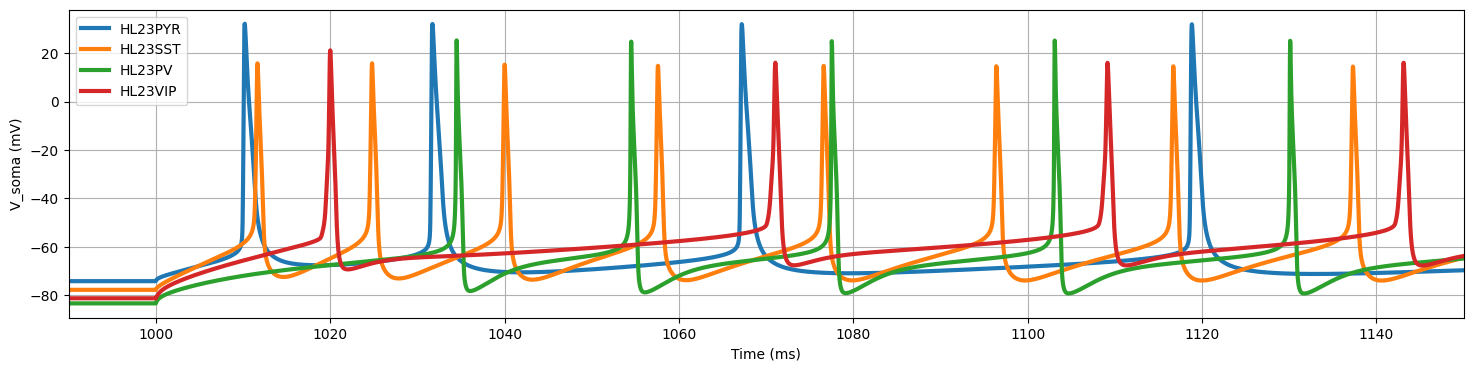

In [14]:
fig = plt.figure(figsize=(18,4))

for i, soma_voltage in enumerate(Traces):
    # plt.subplot(2,2,i+1)
    plt.plot(time,soma_voltage, linewidth=3, label=TracesList[i])
    plt.xlabel('Time (ms)')
    plt.ylabel('V_soma (mV)')
    plt.xlim(990,1150.0)
    # plt.ylim(-70,-60)
    plt.grid(True)
    plt.legend()

# fig.savefig('{s1}/{s}_BBP_changingT.png'.format(s1=outFolder,s=folder[cellnumber]))

## NetPyNE

In [5]:
from netpyne import sim, specs
import pickle

cfg = specs.SimConfig()     

cfg.duration = 2000 ## Duration of the sim, in ms  
cfg.dt = 0.025
cfg.seeds = {'conn': 4321, 'stim': 1234, 'loc': 4321} 
cfg.hParams = {'celsius': 34, 'v_init': -65}  
cfg.verbose = False
cfg.createNEURONObj = True
cfg.createPyStruct = True
cfg.cvode_active = False
cfg.cvode_atol = 1e-6
cfg.cache_efficient = True
cfg.printRunTime = 0.5

cfg.includeParamsLabel = False
cfg.printPopAvgRates = True
cfg.checkErrors = False

allpops = ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']

cfg.recordCells = allpops  # which cells to record from
cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_0': {'sec':'axon_0', 'loc':0.5, 'var':'v'},                  
                    # 'V_dend_5': {'sec':'dend_5', 'loc':0.5, 'var':'v'},
                    }


## Dict with traces to record
cfg.recordStim = True
cfg.recordTime = True
cfg.recordStep = 0.025      

cfg.simLabel = 'L23_Net'
cfg.saveFolder = '.'
cfg.savePickle = False         	## Save pkl file
cfg.saveJson = False           	## Save json file
cfg.saveDataInclude = ['simData' , 'simConfig', 'netParams', 'netParams']
cfg.backupCfgFile = None 		##  
cfg.gatherOnlySimData = False	##  
cfg.saveCellSecs = True			##  
cfg.saveCellConns = True		##  

cfg.analysis['plotTraces'] = {'include': allpops, 'figSize': (12, 4), 'timeRange': [0,cfg.duration], 'saveFig': False, 'overlay': True, 'oneFigPer': 'trace'}  # Plot recorded traces for this list of cells


#------------------------------------------------------------------------------
# Current inputs 
#------------------------------------------------------------------------------
cfg.addIClamp = 1

cfg.IClamp1 = {'pop': 'HL23PYR',  'sec': 'soma_0', 'loc': 0.5, 'start': 1000, 'dur': 1000, 'amp': 0.2}
cfg.IClamp2 = {'pop': 'HL23SST', 'sec': 'soma_0', 'loc': 0.5, 'start': 1000, 'dur': 1000, 'amp': 0.2}
cfg.IClamp3 = {'pop': 'HL23PV', 'sec': 'soma_0', 'loc': 0.5, 'start': 1000, 'dur': 1000, 'amp': 0.2}
cfg.IClamp4 = {'pop': 'HL23VIP', 'sec': 'soma_0', 'loc': 0.5, 'start': 1000, 'dur': 1000, 'amp': 0.2}

In [6]:
netParams = specs.NetParams()   # object of class NetParams to store the network parameters


Ipops = ['HL23SST', 'HL23PV', 'HL23VIP']
Epops = ['HL23PYR']

layer = {'1':[0.0, 250.0], '23': [250.0,1200.0], '23soma': [550.0,1200.0], '4':[1200.0,1580.0], '5': [1580.0,2300.0], '6': [2300.0,3300.0]}  # normalized layer boundaries

#------------------------------------------------------------------------------
# Cell parameters
#------------------------------------------------------------------------------

for cellName in allpops:
    cellRule = netParams.importCellParams(label=cellName, somaAtOrigin=True,
        conds={'cellType': cellName, 'cellModel': 'HH_full'},
        fileName='cellwrapper.py',
        cellName='loadCell_' + cellName,
        cellInstance = True,
        cellArgs={'cellName': cellName})
    
# for cellName in allpops:
#     cellRule = netParams.importCellParams(label=cellName, somaAtOrigin=False,
#         conds={'cellType': cellName, 'cellModel': 'HH_full'},
#         fileName='cellwrapper.py',
#         cellName='loadCell',
#         cellInstance = True,
#         cellArgs={'cellName': cellName, 'rseed': 7313766})
    
#------------------------------------------------------------------------------
# Population parameters
#------------------------------------------------------------------------------
# cell_num = [800, 50, 70, 80]
# cell_num = [19, 2, 2, 2]
# cell_num = [8, 5, 7, 8]
cell_num = [1, 1, 1, 1]

for ii,cellName in enumerate(['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']):
    netParams.popParams[cellName] = {'cellType': cellName, 'cellModel': 'HH_full', 'numCells': cell_num[ii], 'yRange': layer['23soma']} 

#------------------------------------------------------------------------------
# Current inputs (IClamp)
#------------------------------------------------------------------------------
if cfg.addIClamp:
     for key in [k for k in dir(cfg) if k.startswith('IClamp')]:
        params = getattr(cfg, key, None)
        [pop,sec,loc,start,dur,amp] = [params[s] for s in ['pop','sec','loc','start','dur','amp']]

        #cfg.analysis['plotTraces']['include'].append((pop,0))  # record that pop

        # add stim source
        netParams.stimSourceParams[key] = {'type': 'IClamp', 'delay': start, 'dur': dur, 'amp': amp}

        # connect stim source to target
        netParams.stimTargetParams[key+'_'+pop] =  {
            'source': key, 
            'conds': {'pop': pop},
            'sec': sec, 
            'loc': loc}

NeuronTemplate_HL23PYR[0]
NeuronTemplate_HL23SST[0]
NeuronTemplate_HL23PV[0]
NeuronTemplate_HL23VIP[0]


## Run 

In [7]:
sim.initialize(
    simConfig = cfg, 	
    netParams = netParams)  				# create network object and set cfg and net params
sim.net.createPops()               			# instantiate network populations
sim.net.createCells()              			# instantiate network cells based on defined populations
# sim.net.defineCellShapes()  # in case some cells had stylized morphologies without 3d pts
sim.net.connectCells()            			# create connections between cells based on params
sim.net.addStims() 							# add network stimulation
sim.setupRecording()              			# setup variables to record for each cell (spikes, V traces, etc)


Start time:  2026-04-07 10:28:08.104103

Creating network of 4 cell populations on 1 hosts...
  Number of cells on node 0: 4 
  Done; cell creation time = 0.03 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 4 
  Done; cell stims creation time = 0.00 s.
Recording 8 traces of 2 types on node 0


{spkt: Vector[0], spkid: Vector[1], stims: {cell_0: {}, cell_1: {}, cell_2: {}, cell_3: {}}, V_soma: {cell_0: Vector[6], cell_1: Vector[7], cell_2: Vector[8], cell_3: Vector[9]}, t: Vector[10], _repr_mimebundle_: {}}

In [8]:
for metype in sim.net.cells:
    print('cell ->', metype.tags['cellType'], metype.tags['cellModel'], metype.tags['pop'])
    if metype.tags['cellType'] == 'HL23PYR':
        metype.secs['axon_0']['hObj'](0.1).diam = 2.875
        metype.secs['axon_0']['hObj'](0.3).diam = 2.625
        metype.secs['axon_0']['hObj'](0.5).diam = 2.375
        metype.secs['axon_0']['hObj'](0.7).diam = 2.125
        metype.secs['axon_0']['hObj'](0.9).diam = 1.875

        metype.secs['axon_1']['hObj'](0.0714286).diam = 1.6964285714285714
        metype.secs['axon_1']['hObj'](0.214286).diam = 1.5892857142857142
        metype.secs['axon_1']['hObj'](0.357143).diam = 1.4821428571428572
        metype.secs['axon_1']['hObj'](0.5).diam = 1.375
        metype.secs['axon_1']['hObj'](0.642857).diam = 1.2678571428571428
        metype.secs['axon_1']['hObj'](0.785714).diam = 1.1607142857142856
        metype.secs['axon_1']['hObj'](0.928571).diam = 1.0535714285714286

    if metype.tags['cellType'] == 'HL23SST':
        metype.secs['axon_0']['hObj'](0.1).diam = 2.875
        metype.secs['axon_0']['hObj'](0.3).diam = 2.625
        metype.secs['axon_0']['hObj'](0.5).diam = 2.375
        metype.secs['axon_0']['hObj'](0.7).diam = 2.125
        metype.secs['axon_0']['hObj'](0.9).diam = 1.875

        metype.secs['axon_1']['hObj'](0.0714286).diam = 1.6964285714285714
        metype.secs['axon_1']['hObj'](0.214286).diam = 1.5892857142857142
        metype.secs['axon_1']['hObj'](0.357143).diam = 1.4821428571428572
        metype.secs['axon_1']['hObj'](0.5).diam = 1.375
        metype.secs['axon_1']['hObj'](0.642857).diam = 1.2678571428571428
        metype.secs['axon_1']['hObj'](0.785714).diam = 1.1607142857142856
        metype.secs['axon_1']['hObj'](0.928571).diam = 1.0535714285714286

cell -> HL23PYR HH_full HL23PYR
cell -> HL23SST HH_full HL23SST
cell -> HL23PV HH_full HL23PV
cell -> HL23VIP HH_full HL23VIP


In [9]:
sim.runSim()                      			# run parallel Neuron simulation  
sim.gatherData()                  			# gather spiking data and cell info from each node
# sim.saveData()                    			# save params, cell info and sim output to file (pickle,mat,txt,etc)#
# sim.analysis.plotData()         			# plot spike raster etc
# sim.analysis.plotShape()  

0.0s

Running simulation using NEURON for 2000.0 ms...
0.5s
1.0s
1.5s
2.0s
  Done; run time = 2.65 s; real-time ratio: 0.75.

Gathering data...
  Done; gather time = 0.02 s.

Analyzing...
  Cells: 4
  Connections: 0 (0.00 per cell)
  Spikes: 129 (16.12 Hz)
  Simulated time: 2.0 s; 1 workers
  Run time: 2.65 s
   HL23PYR : 8.500 Hz
   HL23SST : 24.000 Hz
   HL23PV : 16.500 Hz
   HL23VIP : 15.500 Hz


{spkt: [6.175000000100054, 1010.1000000015833, 1011.6250000015889, 1019.9250000016191, 1024.600000001636, 1031.975000001663, 1034.450000001672, 1039.8500000016916, 1053.8500000017425, 1057.6250000017562, 1070.7000000018038, 1074.600000001818, 1076.2000000018238, 1076.8500000018262, 1096.8000000018988, 1101.3250000019152, 1113.4500000019593, 1117.1750000019729, 1128.0500000020124, 1129.3750000020173, 1137.825000002048, 1148.0750000020853, 1155.7750000021133, 1158.6750000021239, 1179.6250000022, 1181.275000002206, 1184.2250000022168, 1198.7500000022696, 1200.6750000022766, 1213.2500000023224, 1213.8500000023246, 1221.7750000023534, 1242.7500000024297, 1242.9250000024304, 1246.0500000024417, 1264.1250000025075, 1269.8750000025284, 1272.6250000025384, 1278.000000002558, 1285.3250000025846, 1302.8000000026482, 1306.5500000026618, 1309.7500000026735, 1327.775000002739, 1333.2250000027589, 1341.1000000027875, 1341.3000000027882, 1349.0250000028163, 1363.80000000287, 1370.2750000028936, 1372.7

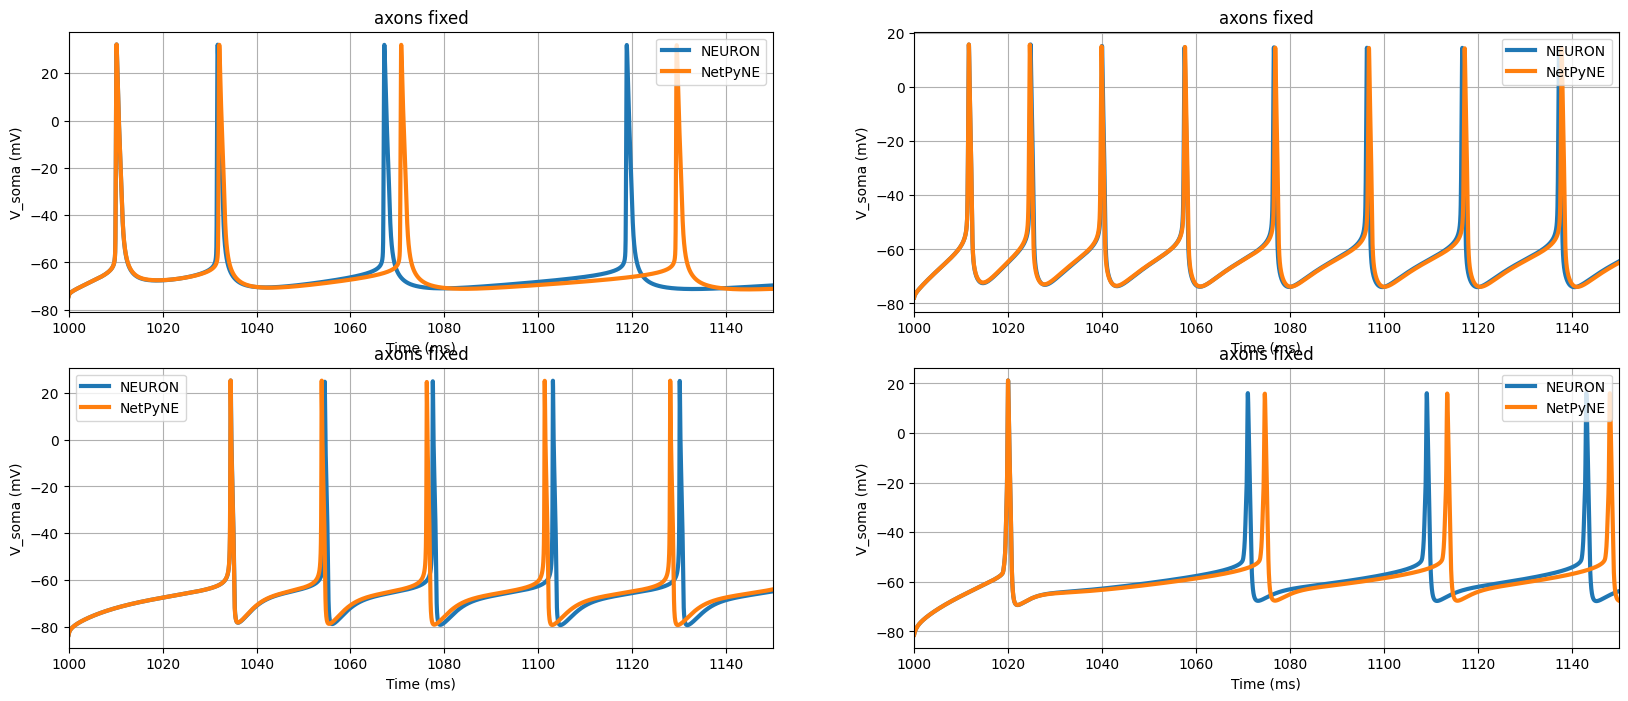

In [10]:
fig = plt.figure(figsize=(20,8))
ll = [0,1,2,3]
for i, soma_voltage in enumerate(Traces):
    plt.subplot(2,2,i+1)
    plt.title('axons fixed')
    plt.plot(time,soma_voltage, linewidth=3, label='NEURON')
    plt.plot(list(sim.simData['t']),list(sim.simData['V_soma']['cell_'+str(ll[i])]), linewidth=3, label='NetPyNE')
    plt.xlabel('Time (ms)')
    plt.ylabel('V_soma (mV)')
    plt.xlim(1000,1150.0)
    # plt.ylim(-70,-60)
    plt.grid(True)
    plt.legend()


fig.savefig('axons_fixed.png')

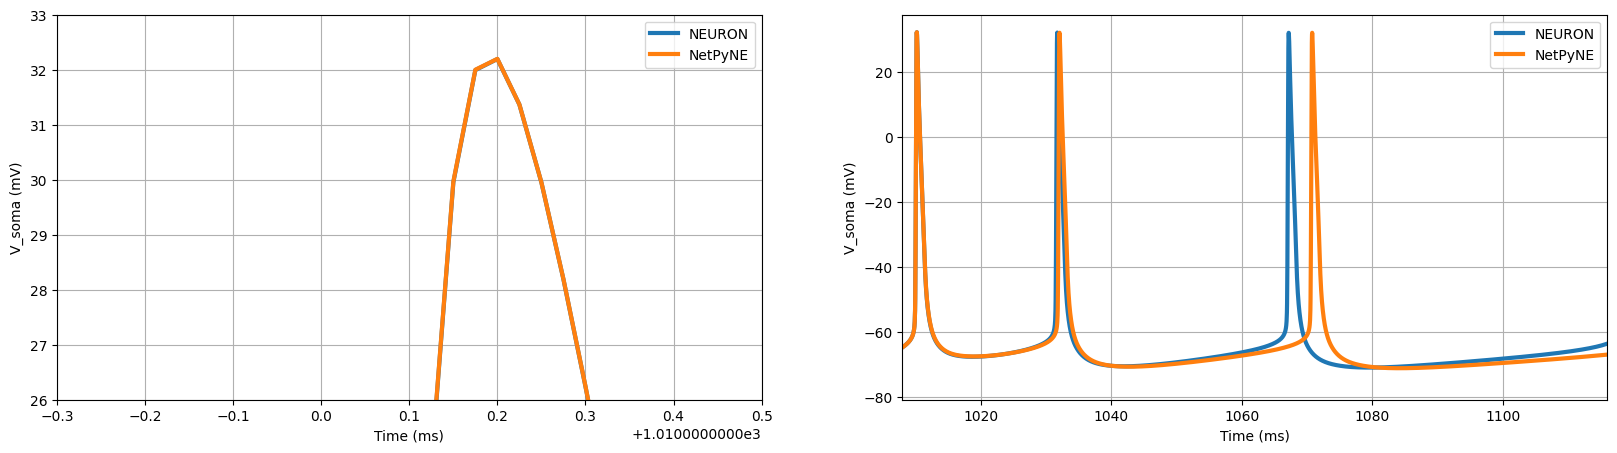

In [11]:

fig = plt.figure(figsize=(20,5))
soma_voltage = Traces[0]
plt.subplot(121)
plt.plot(time,soma_voltage, linewidth=3, label='NEURON')
plt.plot(list(sim.simData['t']),list(sim.simData['V_soma']['cell_0']), linewidth=3, label='NetPyNE')
plt.xlabel('Time (ms)')
plt.ylabel('V_soma (mV)')
plt.xlim(1009.7,1010.5)
# plt.xlim(1008,1116.0)
plt.ylim(26,33)
plt.grid(True)
plt.legend()

plt.subplot(122)
plt.plot(time,soma_voltage, linewidth=3, label='NEURON')
plt.plot(list(sim.simData['t']),list(sim.simData['V_soma']['cell_0']), linewidth=3, label='NetPyNE')
plt.xlabel('Time (ms)')
plt.ylabel('V_soma (mV)')
plt.xlim(1008,1116.0)
# plt.ylim(26,33)
plt.grid(True)
plt.legend()

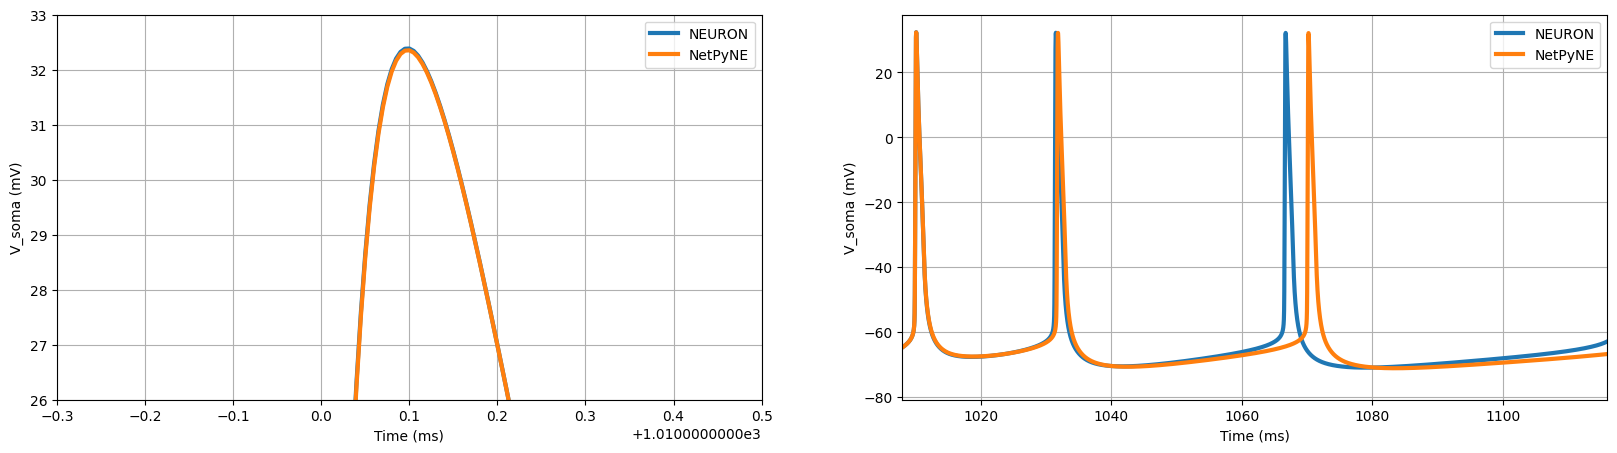